Bases de dados históricos ações - yahoo finance (desde início 2025 apenas em plano Gold)

In [3]:
import pandas as pd
df = pd.read_csv('PETR4.SA2.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,13.660646,30182600
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,14.153233,30552600
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,14.174045,36141000
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,13.931217,28069600
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,13.528824,29091300


In [4]:
#checar missing values e exibir linha
print(df[df.isna().any(axis=1)])
print(df.isnull().sum())

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [5]:
print(df.shape)
#se tiver, pode-se apagar
df = df.dropna()
print(df.shape)

(2234, 7)
(2234, 7)


In [6]:
#considerando serie univariada
y = df['Close']

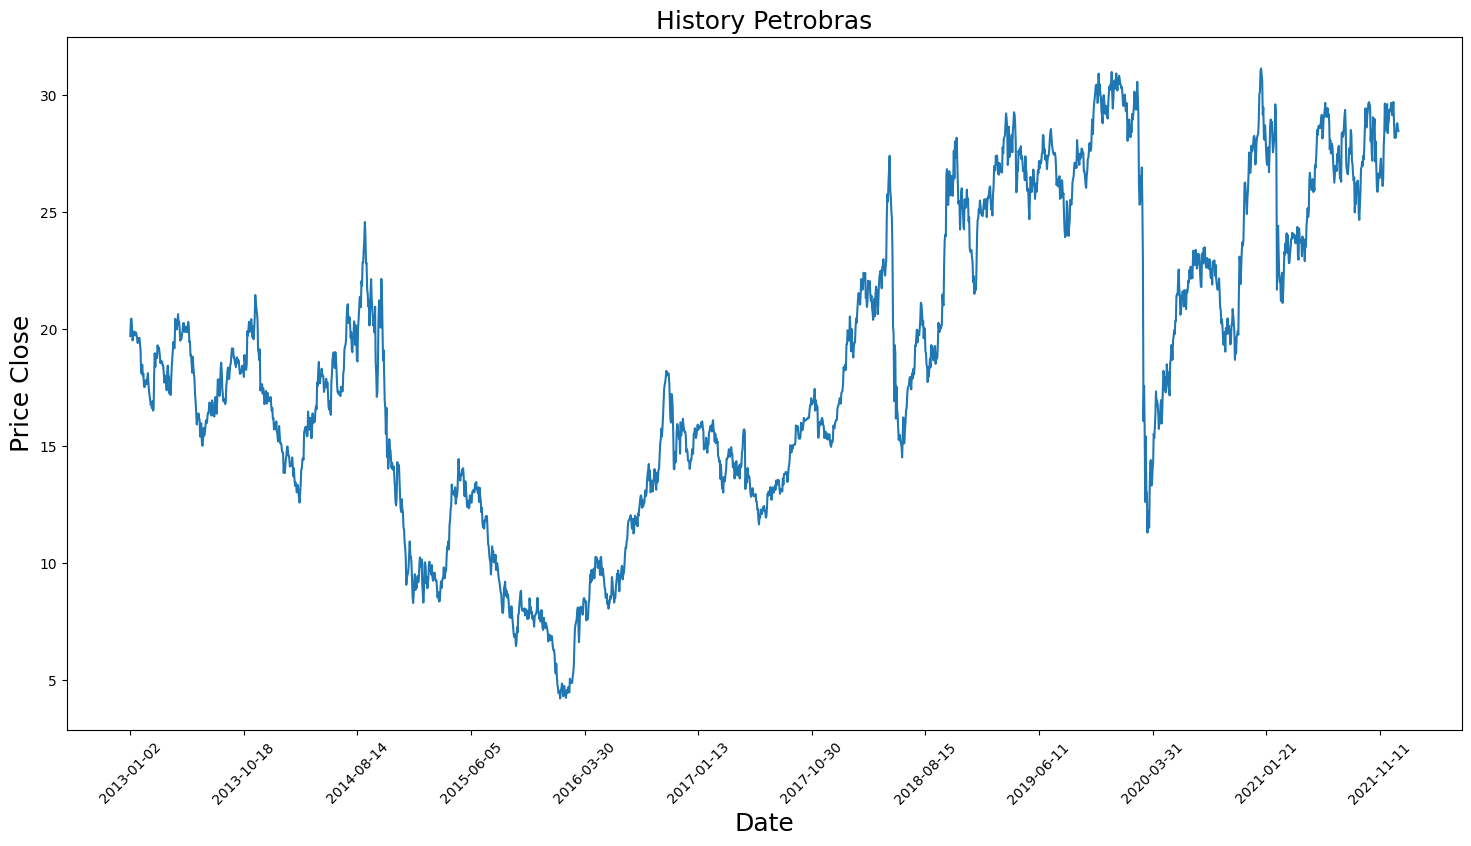

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,9))
plt.plot(y)
plt.xticks(range(0,df.shape[0],200), df['Date'].loc[::200], rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Price Close', fontsize=18)
plt.title('History Petrobras',fontsize=18)
plt.show()

In [7]:
#definir qual a janela de tempo (dias) anterior irá considerar com mais atenção
days_time_step = 15

In [8]:
#vamos agora separar treino, teste
import numpy as np
train_size = int(len(y) * 0.8)
test_size = len(y) - train_size
train, test = np.array(y[0:train_size]), np.array(y[train_size - days_time_step:]) #inclui os 15 dias anteriores

val = np.array(y[train_size:])

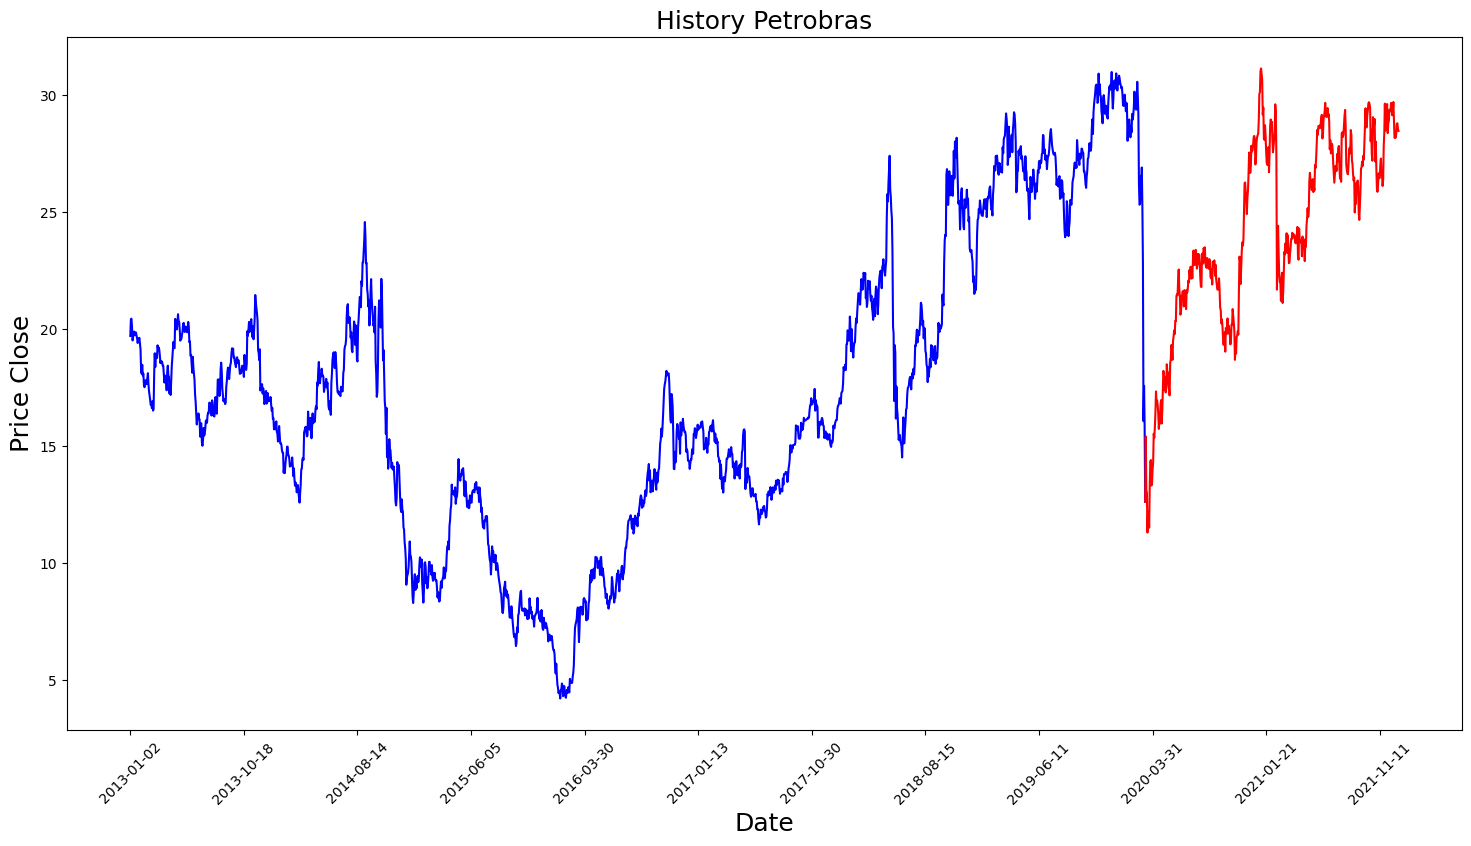

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,9))
plt.plot(y.loc[0:train.shape[0]], color='blue', label='train')
plt.plot(y.loc[train.shape[0]:], color='red', label='test')
plt.xticks(range(0,df.shape[0],200), df['Date'].loc[::200], rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Price Close', fontsize=18)
plt.title('History Petrobras',fontsize=18)
plt.show()

In [ ]:
#LSTM é sensível à escala, sugere-se normalização

In [12]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train.reshape(-1,1))
test_scaled = scaler.fit_transform(test.reshape(-1,1))
val_scaled = scaler.fit_transform(val.reshape(-1,1))

In [15]:
#separar X e y
#treino
X_train, y_train = [], []
for i in range(days_time_step, len(train)):
  X_train.append(train_scaled[i-days_time_step:i])
  y_train.append(train_scaled[i])

#test
X_test = []
for i in range(days_time_step, len(days_time_step + test)):
  X_test.append(test_scaled[i-days_time_step:i])

#val
X_val, y_val = [], []
for i in range(days_time_step, len(val)):
  X_val.append(val_scaled[i-days_time_step:i])
  y_val.append(val_scaled[i])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
X_val = np.array(X_val)
y_val = np.array(y_val)

In [19]:
X_test.shape

(447, 15, 1)

In [20]:
import tensorflow as tf
tf.__version__

'2.19.0'

### Vamos criar primeiro uma RNN Simples

In [39]:
from tensorflow import keras

# Define Sequential model with 3 layers
model = keras.Sequential(
    [
        #recebe os valores de ação em days_time_step dias e retorna só o valor final (many_to_one)
        keras.layers.SimpleRNN(20, return_sequences=False, input_shape=(days_time_step, 1)),
        #keras.layers.Dropout(0.3),
        keras.layers.Dense(1),
    ]
)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 20)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

A camada SimpleRNN com 100 unidades calcula seus parâmetros com base em três conjuntos de pesos e vieses (bias):$$P_{RNN} = (W_{xh} \times h) + (W_{hh} \times h) + (B_h \times h) $$Onde:
- $W_{xh}$: Pesos da entrada para o estado oculto (Hidden State); Conectam a entrada (1 feature) a cada unidade RNN (100 unidades).
- $W_{hh}$: Pesos do estado oculto anterior para o estado oculto atual; Conectam o estado oculto anterior (100 unidades) ao estado oculto atual (100 unidades).
- $B_h$: Vieses (Bias) do estado oculto; Um valor de viés para cada unidade RNN (100 unidades).
- $i$: Dimensão da entrada (número de features), que é 1.
- $h$: Número de unidades (dimensões do estado oculto), que é 100.

A camada SimpleRNN tem 100 unidades e return_sequences=False. Portanto, sua saída é um vetor de tamanho 100. Essa é a entrada para a camada Dense(1).
A camada Dense tem 1 unidade (saída).

Logo, o total de parâmetros treináveis é:
- $$P_{RNN} = 100 + 10000 + 100 = \mathbf{10200}$$
- $$P_{Dense} = 100 + 1 = \mathbf{101}$$
- $$P_{Total} = P_{RNN} + P_{Dense}$$$$P_{Total} = 10200 + 101 = \mathbf{10301}$$


In [37]:
h = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0737 - val_loss: 0.0041
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0050 - val_loss: 0.0032
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0038 - val_loss: 0.0025
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0034 - val_loss: 0.0021
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0036
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0016
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0018
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 9/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 10/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 11/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 12/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - va

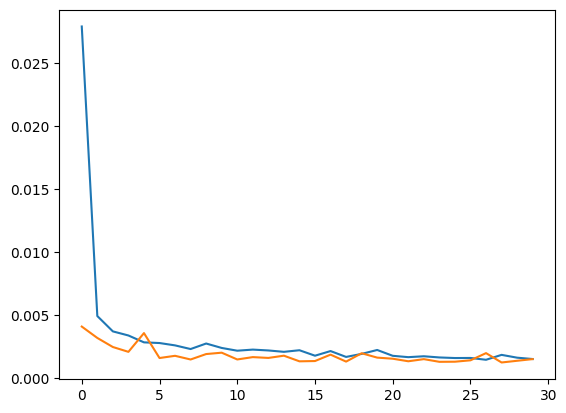

In [40]:
import matplotlib.pyplot as plt
#plt.figure(figsize=(18,9))
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')

In [47]:
predict = model.predict(X_test)
predict = scaler.inverse_transform(predict)
real = test
predict.shape

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


(447, 1)

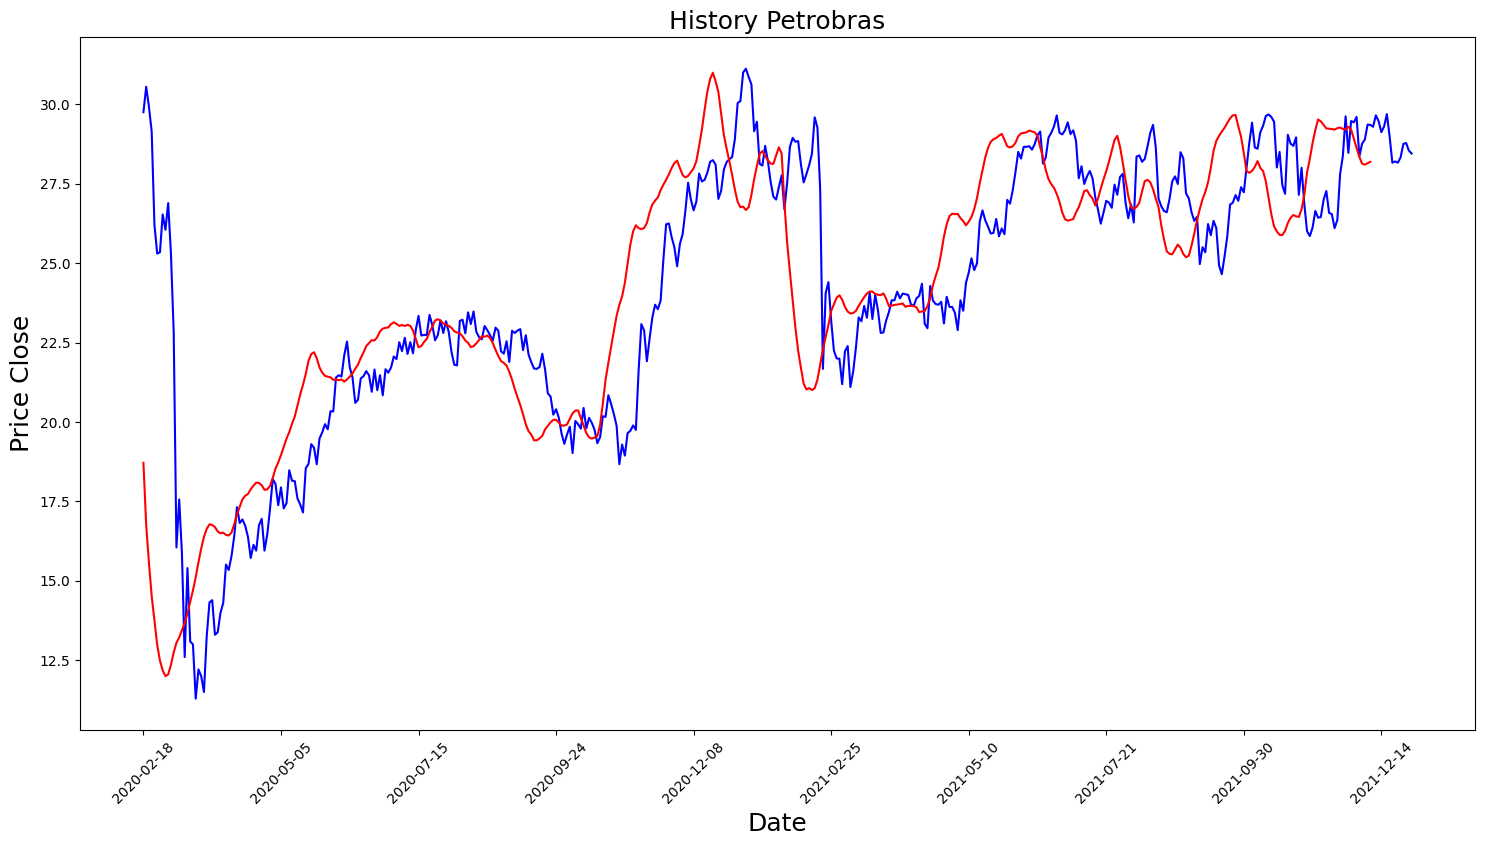

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,9))
plt.plot(real, color='blue', label='actual_test')
plt.plot(predict, color='red', label='forecast')
plt.xticks(range(0,len(real),50), df['Date'].iloc[-len(real)::50], rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Price Close', fontsize=18)
plt.title('History Petrobras',fontsize=18)
plt.show()

### Vamos testar agora LSTM

In [61]:
from tensorflow import keras

# Define Sequential model with 3 layers
model = keras.Sequential(
    [
        #recebe os valores de ação em days_time_step dias e retorna só o valor final (many_to_one)
        keras.layers.LSTM(50, return_sequences=True, input_shape=(days_time_step, 1)),
        keras.layers.Dropout(0.1),
        keras.layers.LSTM(50, return_sequences=False, input_shape=(days_time_step, 1)),
        #keras.layers.Dropout(0.3),
        keras.layers.Dense(1),
    ]
)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 15, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
h = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0491 - val_loss: 0.0048
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0025 - val_loss: 0.0048
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022 - val_loss: 0.0049
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0024 - val_loss: 0.0047
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0021 - val_loss: 0.0060
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022 - val_loss: 0.0041
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0023 - val_loss: 0.0038
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0021 - val_loss: 0.0037
Epoch 9/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019 - val_loss: 0.0037
Epoch 10/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0020 - val_loss: 0.0033
Epoch 11/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0018 - val_loss: 0.0031
Epoch 12/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

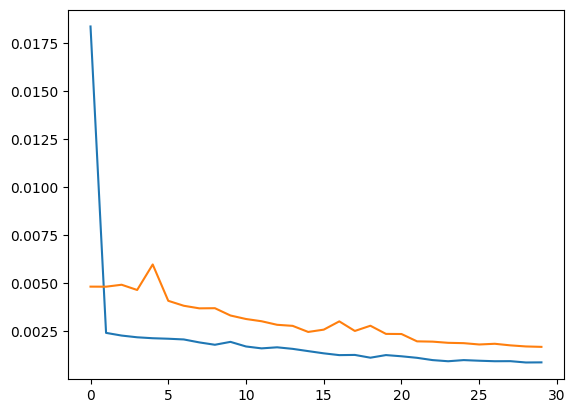

In [63]:
import matplotlib.pyplot as plt
#plt.figure(figsize=(18,9))
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')

Se a val_loss ficar abaixo da train_loss:
1. Regularização (Principalmente Dropout)
A train_loss é calculada com Regularização: Camadas de regularização como o Dropout são ativas apenas durante o treinamento. O Dropout "desliga" aleatoriamente algumas unidades neurais, o que aumenta artificialmente a train_loss em cada época, pois o modelo não consegue usar sua capacidade total.

A val_loss é calculada SEM Regularização: Quando o modelo é avaliado no conjunto de validação, as camadas de Dropout são desativadas. O modelo usa sua capacidade total e, portanto, alcança uma perda menor e mais precisa.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


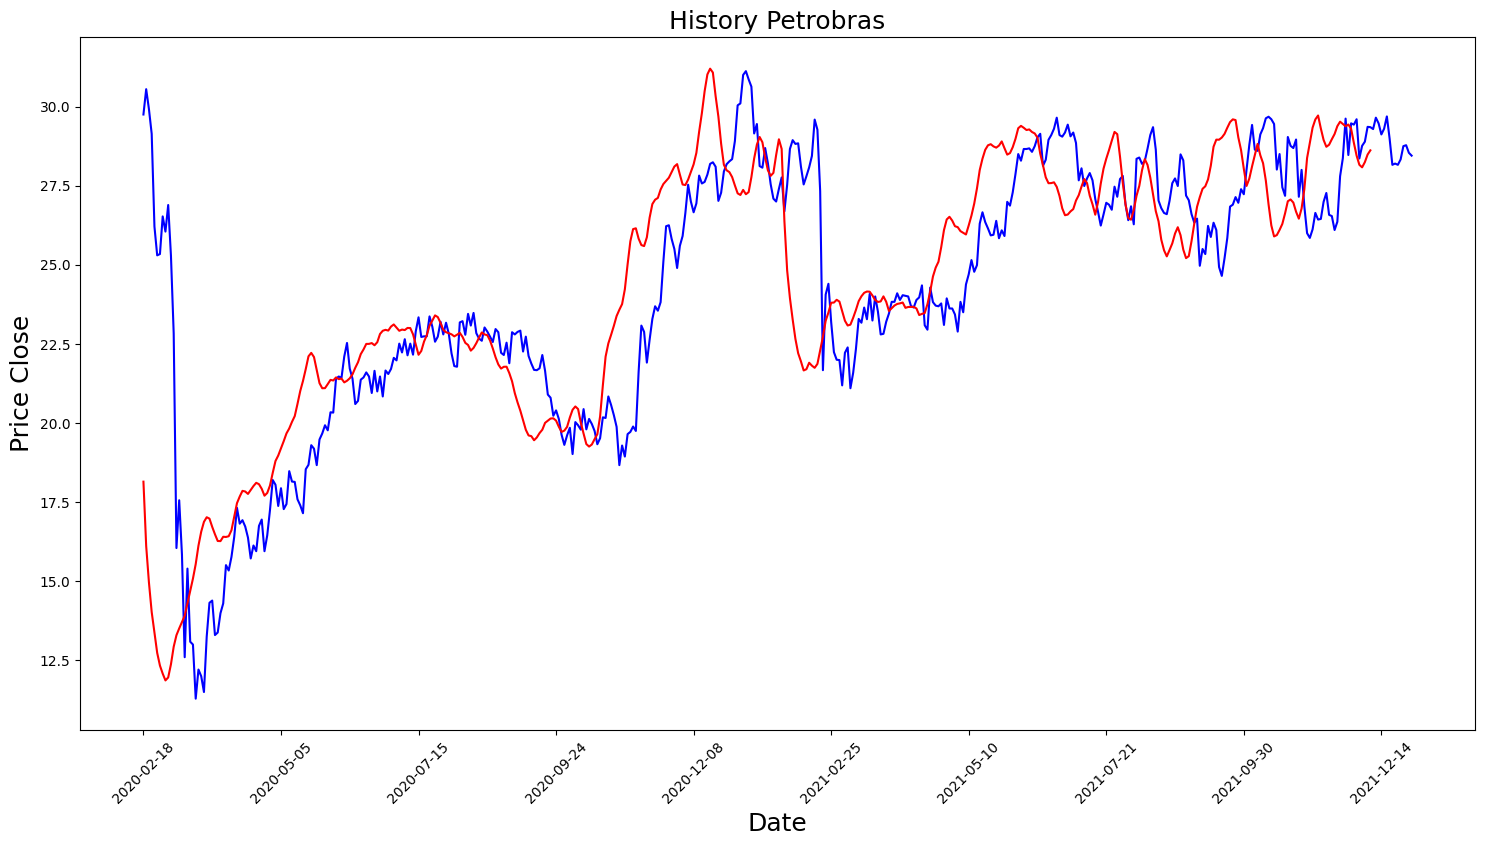

In [64]:
predict = model.predict(X_test)
predict = scaler.inverse_transform(predict)
real = test

import matplotlib.pyplot as plt
plt.figure(figsize=(18,9))
plt.plot(real, color='blue', label='actual_test')
plt.plot(predict, color='red', label='forecast')
plt.xticks(range(0,len(real),50), df['Date'].iloc[-len(real)::50], rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Price Close', fontsize=18)
plt.title('History Petrobras',fontsize=18)
plt.show()